# 02 — Correlazioni e rischio di portafoglio

Domanda a cui risponde: **quanto del mio 'hedge' è illusorio?** GOOGL long-growth + spread short-SPCX (short-growth) si sovrappongono. Pearson di lungo periodo vs EWMA (λ=0.94, RiskMetrics) che pesa gli ultimi ~30 giorni: se divergono, il regime sta cambiando.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, PALETTE
tufte_style()

In [2]:
from src.risk.metrics import log_returns, corr_matrix, ewma_corr, summary_table
prices = pd.read_parquet("../data/universe_prices.parquet").dropna()
rets = log_returns(prices)
summary = summary_table(prices)
summary

,vol_annua,beta_vs_SP500,max_drawdown,ret_tot_periodo
GOOGL,0.2974,1.2796,-0.2037,0.1361
TSLA,0.4007,1.7526,-0.2993,-0.0941
NDAQ,0.2954,0.7506,-0.2176,-0.0529
HOOD,0.7220,3.1948,-0.5197,-0.3731
VIRT,0.3462,0.4545,-0.1140,0.4980
GS,0.3285,1.7168,-0.1942,0.1866
MS,0.3043,1.5196,-0.1883,0.1939
^GSPC,0.1349,1.0083,-0.0910,0.0754
^NDX,0.1904,1.3428,-0.1180,0.1411


## Heatmap: correlazione storica (2y) vs EWMA (regime corrente)

Lettura: TSLA è il proxy migliore della volatilità che avrà SPCX (stesso key-man risk). Se GOOGL-TSLA EWMA > 0.6, il 'beta Musk' contagia anche la tranche difensiva → ridurre aspettative di hedge.

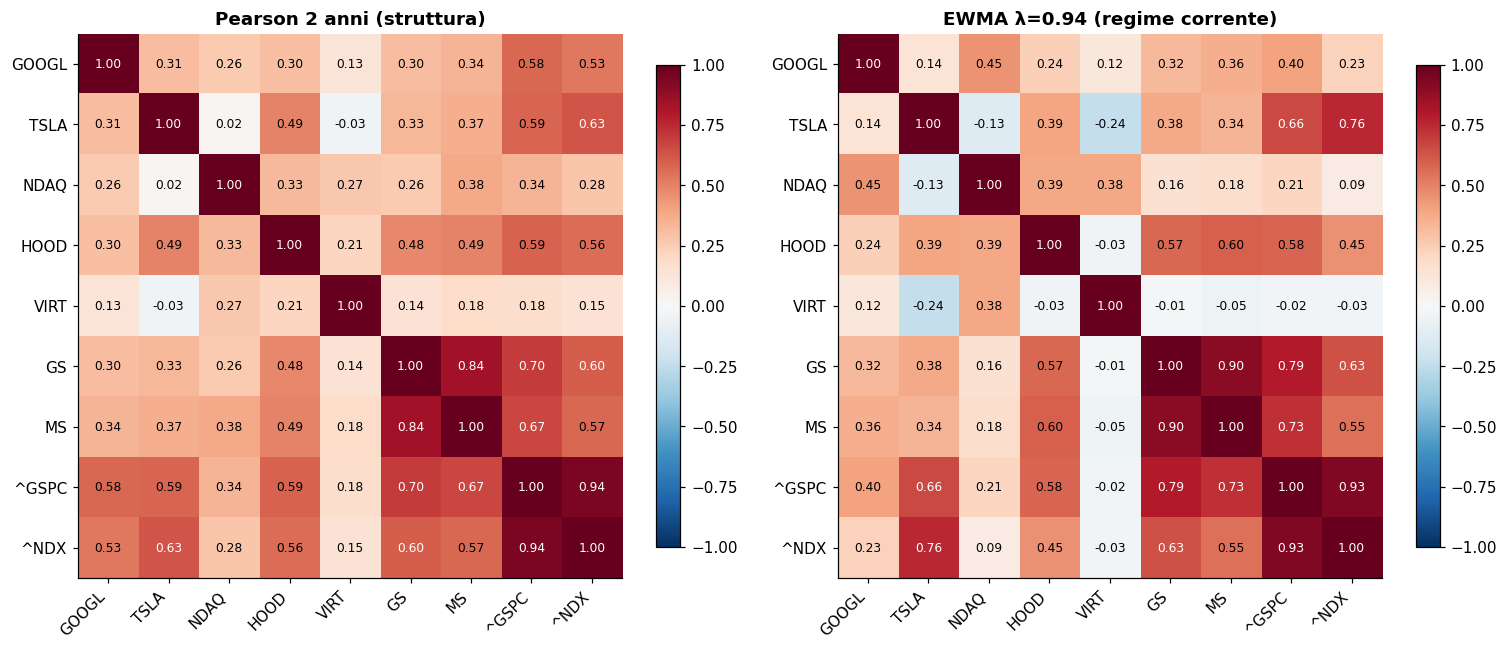

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
corr_heatmap(axes[0], corr_matrix(rets), "Pearson 2 anni (struttura)")
corr_heatmap(axes[1], ewma_corr(rets), "EWMA λ=0.94 (regime corrente)")
fig.tight_layout(); fig.savefig("../data/chart_corr.png", bbox_inches="tight"); plt.show()

## Correlazione rolling 60g GOOGL vs mercato

Se sale verso 1 nei drawdown (succede quasi sempre), la diversificazione svanisce quando serve: è il motivo per cui l'unico hedge vero del piano è l'hard cap dello spread, non la correlazione.

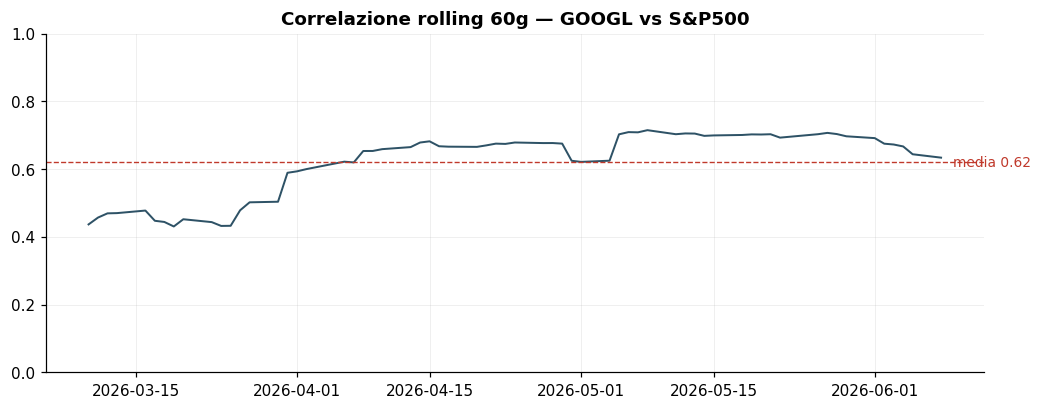

In [4]:
roll = rets["GOOGL"].rolling(60).corr(rets["^GSPC"]).dropna()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll.index, roll.values, lw=1.3)
ax.axhline(roll.mean(), color=PALETTE[1], lw=0.9, ls="--")
ax.annotate(f"media {roll.mean():.2f}", (roll.index[-1], roll.mean()), xytext=(8, 0), textcoords="offset points", color=PALETTE[1], fontsize=9, va="center")
ax.set_title("Correlazione rolling 60g — GOOGL vs S&P500")
ax.set_ylim(0, 1)
fig.savefig("../data/chart_rolling_corr.png", bbox_inches="tight"); plt.show()

## Risk ledger del piano (€2.000)

| Posizione | Rischio | Cap |
|---|---|---|
| GOOGL €1.200 | beta × drawdown mercato | soft (stop -15%) |
| Spread €205 | premio pagato | **hard** |
| Cash €400 | zero | hard |

Il VaR vero del piano lo calcola il notebook 03 col Monte Carlo: le correlazioni qui sopra sono i suoi input qualitativi.